# 🎓 DLP Africa — Student Registration Report

**Import Raw Data File**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving DLP AFRICA STUDENT REGISTRATION REPORT.xlsx to DLP AFRICA STUDENT REGISTRATION REPORT.xlsx


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

FILE = "DLP AFRICA STUDENT REGISTRATION REPORT.xlsx"

df = pd.read_excel(FILE, sheet_name="REGISTRATION REPORT", header=1)

# Keep only the 7 main columns
df = df.iloc[:, :7]
df.columns = ["ID", "NAME", "COURSE", "GENDER", "AGE", "AGE GROUP", "DATE"]

# Clean up data types
df = df.dropna(subset=["ID"])
df["ID"]  = df["ID"].astype(int)
df["AGE"] = df["AGE"].astype(int)
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head(10)

Rows: 40, Columns: 7


,ID,NAME,COURSE,GENDER,AGE,AGE GROUP,DATE
0,1,CHIDI OBI,DATA ANALYSIS,MALE,20,20-22,2026-01-05
1,2,AMAKE OKAFOR,WEB DEVELOPMENT,FEMALE,21,20-22,2026-03-05
2,3,SEUN AJIBOLA,DIGITAL MARKETING,MALE,24,23-25,2026-09-05
3,4,NANA HAWA,DATA ANALYSIS,FEMALE,25,23-25,2026-04-05
4,5,MIKE OPARA,FRONT END DEVELOPER,MALE,23,23-25,2026-03-05
5,6,OKE PAUL,BACK END DEVELOPER,MALE,20,20-22,2026-04-05
6,7,JOHN PAUL,UI/UX DESIGN,MALE,22,20-22,2026-05-05
7,8,DORCAS OJO,VIDEO EDITOR,FEMALE,26,26-28,2026-05-05
8,9,CHIOMA IGWE,DATA ANALYSIS,FEMALE,27,26-28,2026-02-05
9,10,BOLA BELLO,FRONT END DEVELOPER,FEMALE,23,23-25,2026-08-05


**Explore the data**

In [11]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Basic stats:")
df.describe()

Shape: (40, 7)

Data types:
ID                    int64
NAME                 object
COURSE               object
GENDER               object
AGE                   int64
AGE GROUP            object
DATE         datetime64[ns]
dtype: object

Missing values:
ID           0
NAME         0
COURSE       0
GENDER       0
AGE          0
AGE GROUP    0
DATE         0
dtype: int64

Basic stats:


,ID,AGE,DATE
count,40.000000,40.000000,40
mean,20.500000,23.325000,2026-04-26 11:24:00
min,1.000000,20.000000,2026-01-05 00:00:00
25%,10.750000,21.000000,2026-03-05 00:00:00
50%,20.500000,23.000000,2026-04-20 00:00:00
75%,30.250000,25.000000,2026-06-12 12:00:00
max,40.000000,28.000000,2026-09-05 00:00:00
std,11.690452,2.379264,NaN


**Pivot table — course × gender**

In [13]:
pivot = pd.crosstab(
    df["COURSE"],
    df["GENDER"],
    margins=True,
    margins_name="Grand Total"
)
pivot = pivot.rename_axis("COURSE / GENDER")

# Sort by Grand Total descending (excluding the total row)
body  = pivot.drop("Grand Total").sort_values("Grand Total", ascending=False)
total = pivot.loc[["Grand Total"]]
pivot = pd.concat([body, total])

pivot

GENDER,FEMALE,MALE,Grand Total
COURSE / GENDER,,,
DATA ANALYSIS,3,8,11
FRONT END DEVELOPER,2,3,5
VIDEO EDITOR,4,1,5
BACK END DEVELOPER,1,3,4
DIGITAL MARKETING,2,2,4
VIRTUAL ASSISTANT,2,2,4
WEB DEVELOPMENT,2,2,4
UI/UX DESIGN,0,3,3
Grand Total,16,24,40


**Course count analysis**

,S/N,COURSE,COURSE COUNT,% COUNT,RANK
0,1,DATA ANALYSIS,11,27.5,1
1,2,FRONT END DEVELOPER,5,12.5,2
2,3,VIDEO EDITOR,5,12.5,2
3,4,BACK END DEVELOPER,4,10.0,4
4,5,DIGITAL MARKETING,4,10.0,4
5,6,VIRTUAL ASSISTANT,4,10.0,4
6,7,WEB DEVELOPMENT,4,10.0,4
7,8,UI/UX DESIGN,3,7.5,8


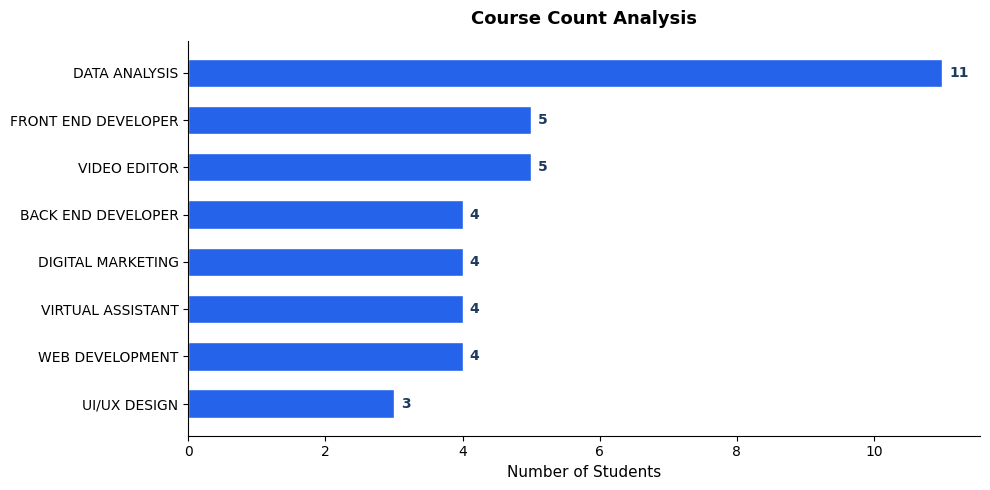

In [15]:
course = (
    df.groupby("COURSE")
      .size()
      .reset_index(name="COURSE COUNT")
      .sort_values("COURSE COUNT", ascending=False)
      .reset_index(drop=True)
)
course["S/N"]     = course.index + 1
course["% COUNT"] = (course["COURSE COUNT"] / len(df) * 100).round(2)
course["RANK"]    = course["COURSE COUNT"].rank(method="min", ascending=False).astype(int)
course = course[["S/N","COURSE","COURSE COUNT","% COUNT","RANK"]]

# Show table
display(course)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    course["COURSE"][::-1],
    course["COURSE COUNT"][::-1],
    color="#2563EB",
    edgecolor="white",
    height=0.6
)

# Add value labels on each bar
for bar in bars:
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va="center", fontsize=10, fontweight="bold", color="#1E3A5F"
    )

ax.set_xlabel("Number of Students", fontsize=11)
ax.set_title("Course Count Analysis", fontsize=13, fontweight="bold", pad=12)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("course_count_chart.png", dpi=150)
plt.show()

**Gender analysis**

,S/N,COURSE,FEMALE,MALE,% MALE,% FEMALE
0,1,DATA ANALYSIS,3,8,33.33,18.75
1,2,FRONT END DEVELOPER,2,3,12.50,12.50
2,3,VIDEO EDITOR,4,1,4.17,25.00
3,4,BACK END DEVELOPER,1,3,12.50,6.25
4,5,DIGITAL MARKETING,2,2,8.33,12.50
5,6,VIRTUAL ASSISTANT,2,2,8.33,12.50
6,7,WEB DEVELOPMENT,2,2,8.33,12.50
7,8,UI/UX DESIGN,0,3,12.50,0.00


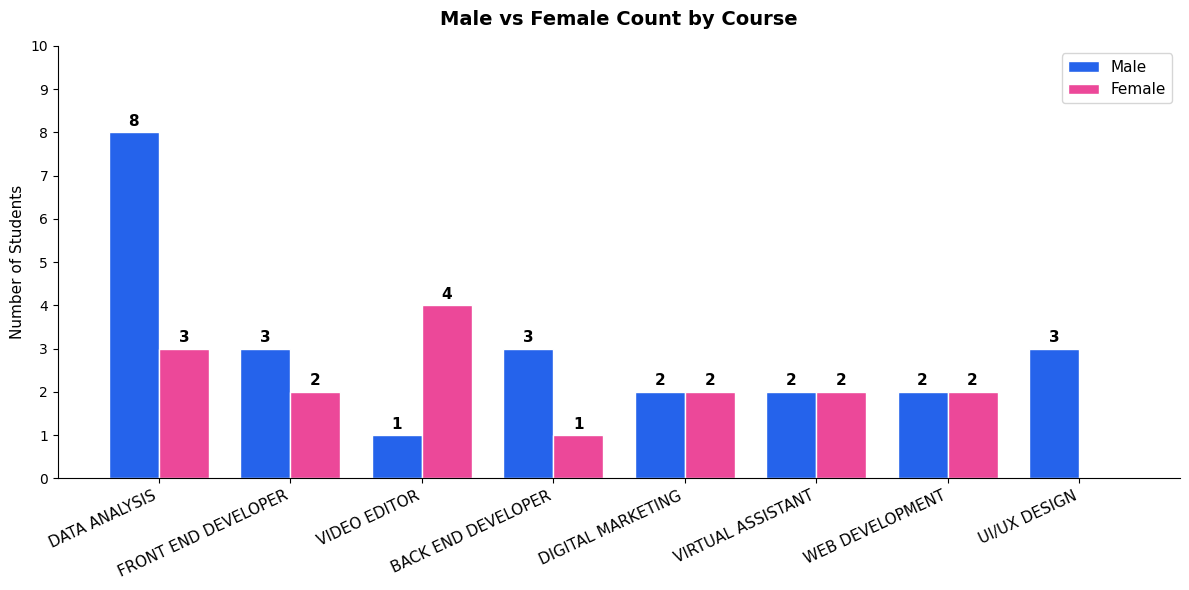

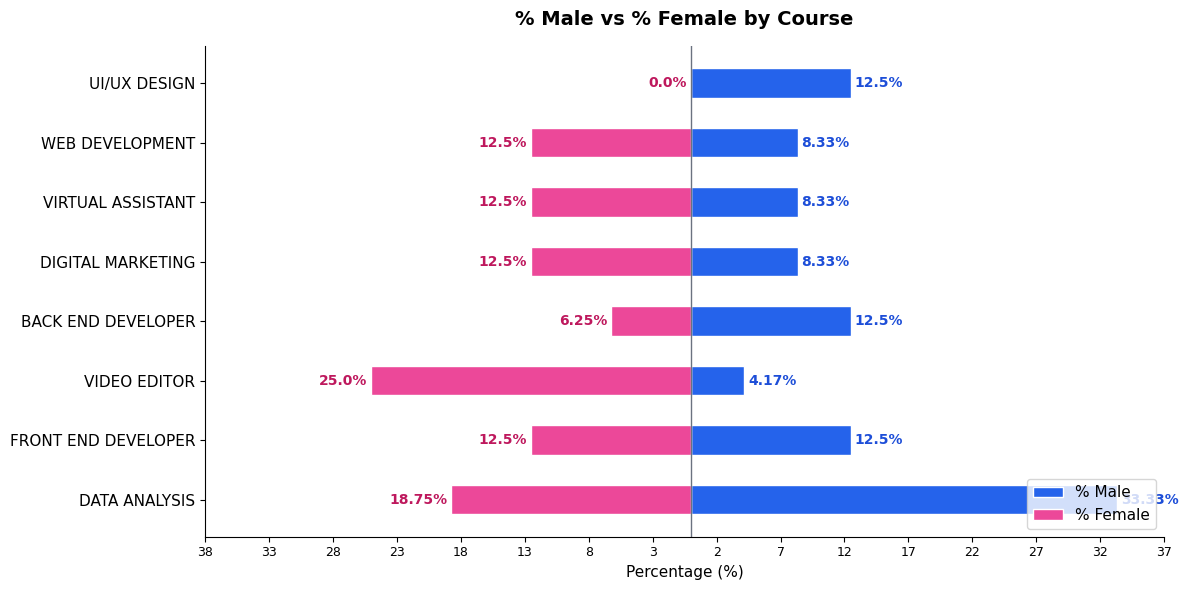

In [18]:
gender = (
    df.groupby(["COURSE","GENDER"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)
gender.columns.name = None

total_m = gender["MALE"].sum()
total_f = gender["FEMALE"].sum()

gender["% MALE"]   = (gender["MALE"]   / total_m * 100).round(2)
gender["% FEMALE"] = (gender["FEMALE"] / total_f * 100).round(2)
gender["TOTAL"]    = gender["MALE"] + gender["FEMALE"]

# Sort by total descending (hierarchy order)
gender = gender.sort_values("TOTAL", ascending=False).reset_index(drop=True)
gender.insert(0, "S/N", range(1, len(gender)+1))

# Show table
display(gender.drop(columns=["TOTAL"]))

# ── Chart 1 — Grouped bar: Male vs Female count ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(gender))
w = 0.38

b1 = ax.bar(x - w/2, gender["MALE"],   w, label="Male",   color="#2563EB", edgecolor="white")
b2 = ax.bar(x + w/2, gender["FEMALE"], w, label="Female", color="#EC4899", edgecolor="white")

for b in list(b1) + list(b2):
    if b.get_height() > 0:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.08,
            int(b.get_height()),
            ha="center", va="bottom", fontsize=11, fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(gender["COURSE"], rotation=25, ha="right", fontsize=11)
ax.set_ylabel("Number of Students", fontsize=11)
ax.set_title("Male vs Female Count by Course", fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.set_ylim(0, gender[["MALE","FEMALE"]].max().max() + 2)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("gender_count_chart.png", dpi=150)
plt.show()

# ── Chart 2 — Diverging bar: % Male vs % Female ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

courses = gender["COURSE"].tolist()
y = np.arange(len(courses))

ax.barh(y,  gender["% MALE"],            height=0.5, color="#2563EB", label="% Male",   edgecolor="white")
ax.barh(y, -gender["% FEMALE"],          height=0.5, color="#EC4899", label="% Female", edgecolor="white")

# Value labels
for i, (m, f) in enumerate(zip(gender["% MALE"], gender["% FEMALE"])):
    ax.text( m + 0.3, i, f"{m}%",  va="center", fontsize=10, fontweight="bold", color="#1D4ED8")
    ax.text(-f - 0.3, i, f"{f}%",  va="center", ha="right", fontsize=10, fontweight="bold", color="#BE185D")

ax.set_yticks(y)
ax.set_yticklabels(courses, fontsize=11)
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_xlabel("Percentage (%)", fontsize=11)
ax.set_title("% Male vs % Female by Course", fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="lower right")
ax.spines[["top","right"]].set_visible(False)

# Show positive labels on x-axis
max_val = max(gender["% MALE"].max(), gender["% FEMALE"].max()) + 5
ticks = np.arange(-int(max_val), int(max_val)+1, 5)
ax.set_xticks(ticks)
ax.set_xticklabels([abs(t) for t in ticks], fontsize=9)

plt.tight_layout()
plt.savefig("gender_percent_chart.png", dpi=150)
plt.show()


**Age analysis**

         AGE BREAKDOWN


,AGE,COUNT,MALE,FEMALE,% COUNT
0,20,6,3,3,15.0
1,21,5,2,3,12.5
2,22,5,4,1,12.5
3,23,6,4,2,15.0
4,24,5,4,1,12.5
5,25,4,3,1,10.0
6,26,4,1,3,10.0
7,27,4,2,2,10.0
8,28,1,1,0,2.5


         AGE GROUP SUMMARY


,AGE GROUP,COUNT,% COUNT
0,20-22,16,40.0
1,23-25,15,37.5
2,26-28,9,22.5


   AVERAGE AGE:  23.32 years


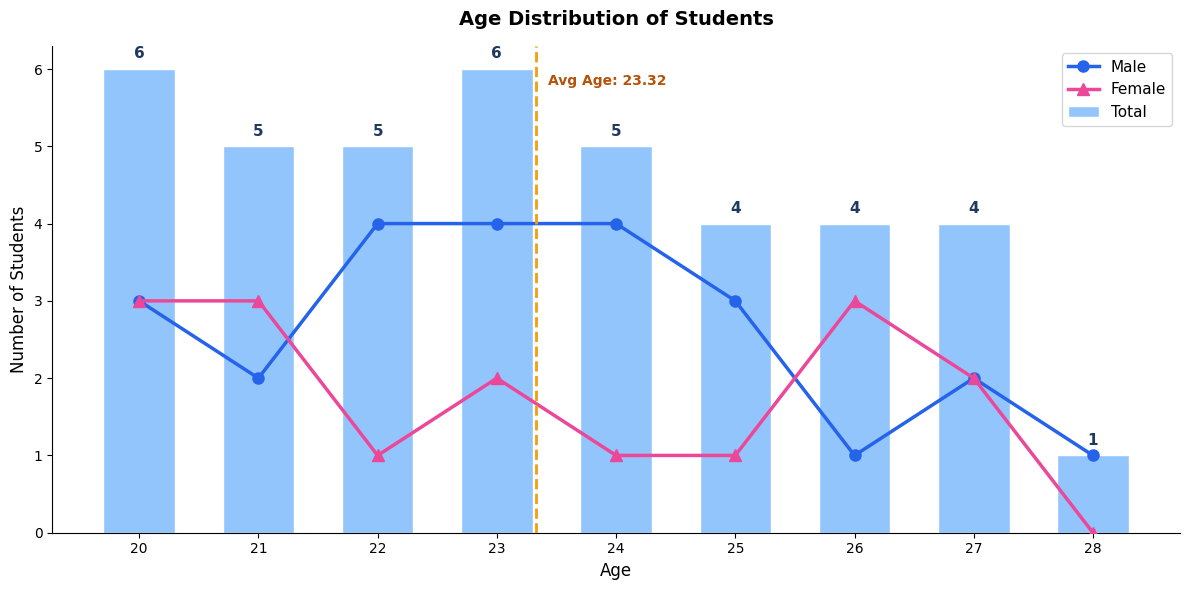

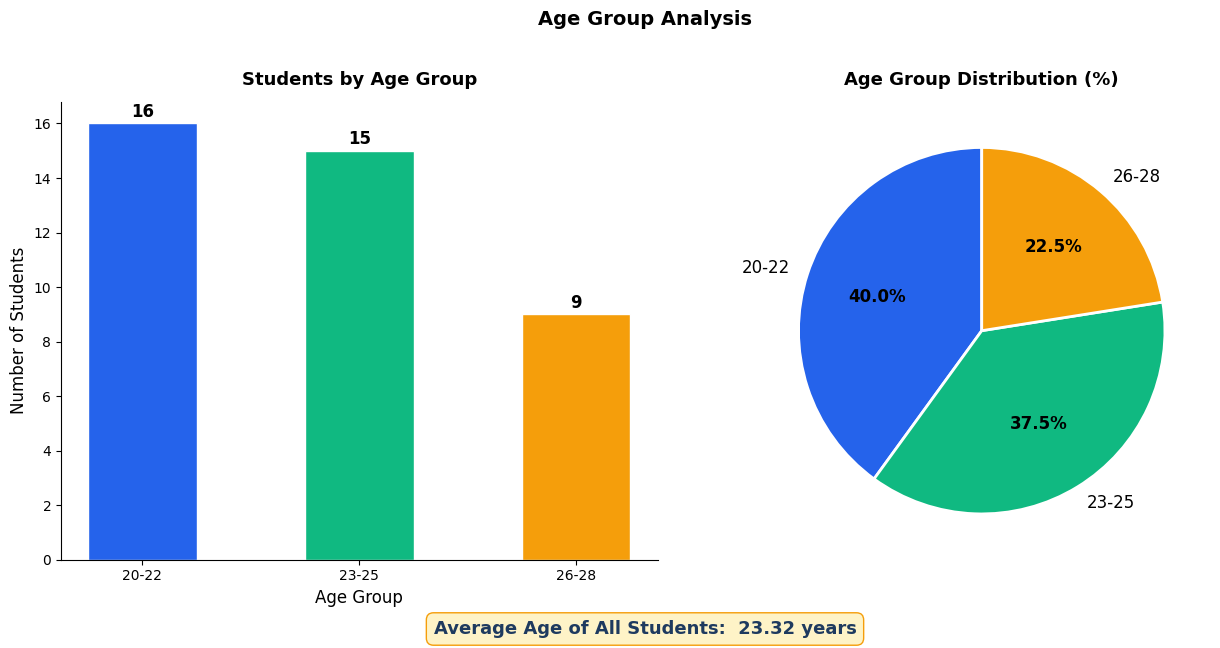

In [19]:
# By individual age
age = (
    df.groupby("AGE")
      .agg(COUNT=("ID","count"),
           MALE=("GENDER", lambda x: (x=="MALE").sum()),
           FEMALE=("GENDER", lambda x: (x=="FEMALE").sum()))
      .reset_index()
)
age["% COUNT"] = (age["COUNT"] / len(df) * 100).round(2)

# By age group
age_grp = (
    df.groupby("AGE GROUP")
      .size()
      .reset_index(name="COUNT")
      .sort_values("AGE GROUP")
)
age_grp["% COUNT"] = (age_grp["COUNT"] / len(df) * 100).round(2)

avg_age = df["AGE"].mean()

# ── Display tables ────────────────────────────────────────────────────────────
print("=" * 45)
print("         AGE BREAKDOWN")
print("=" * 45)
display(age)

print("=" * 45)
print("         AGE GROUP SUMMARY")
print("=" * 45)
display(age_grp)

print("=" * 45)
print(f"   AVERAGE AGE:  {avg_age:.2f} years")
print("=" * 45)

# ── Chart 1 — Age distribution (line + bar) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(age["AGE"], age["COUNT"], color="#93C5FD", edgecolor="white",
       width=0.6, label="Total", zorder=2)
ax.plot(age["AGE"], age["MALE"],   marker="o", color="#2563EB",
        linewidth=2.5, markersize=8, label="Male", zorder=3)
ax.plot(age["AGE"], age["FEMALE"], marker="^", color="#EC4899",
        linewidth=2.5, markersize=8, label="Female", zorder=3)

# Value labels on bars
for _, row in age.iterrows():
    ax.text(row["AGE"], row["COUNT"] + 0.1, int(row["COUNT"]),
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#1E3A5F")

# Average age line
ax.axvline(avg_age, color="#F59E0B", linewidth=2, linestyle="--", zorder=4)
ax.text(avg_age + 0.1, ax.get_ylim()[1] * 0.92,
        f"Avg Age: {avg_age:.2f}", color="#B45309",
        fontsize=10, fontweight="bold")

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of Students", fontsize=12)
ax.set_title("Age Distribution of Students", fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(age["AGE"])
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("age_distribution_chart.png", dpi=150)
plt.show()

# ── Chart 2 — Age group bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colors = ["#2563EB", "#10B981", "#F59E0B"]

# Bar chart
bars = axes[0].bar(age_grp["AGE GROUP"], age_grp["COUNT"],
                   color=colors, edgecolor="white", width=0.5)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        int(bar.get_height()),
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )
axes[0].set_xlabel("Age Group", fontsize=12)
axes[0].set_ylabel("Number of Students", fontsize=12)
axes[0].set_title("Students by Age Group", fontsize=13, fontweight="bold", pad=12)
axes[0].spines[["top","right"]].set_visible(False)
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    age_grp["COUNT"],
    labels=age_grp["AGE GROUP"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")

axes[1].set_title("Age Group Distribution (%)", fontsize=13, fontweight="bold", pad=12)

# Average age annotation
fig.text(0.5, -0.02,
         f"Average Age of All Students:  {avg_age:.2f} years",
         ha="center", fontsize=13, fontweight="bold", color="#1E3A5F",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEF3C7", edgecolor="#F59E0B"))

plt.suptitle("Age Group Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("age_group_chart.png", dpi=150, bbox_inches="tight")
plt.show()

**Lookup functions**

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── VLOOKUP — Search by Student ID ───────────────────────────────────────────
id_input  = widgets.BoundedIntText(value=1, min=1, max=len(df),
                                   description="Student ID:", style={"description_width":"100px"})
id_output = widgets.Output()

def on_id_change(change):
    with id_output:
        clear_output()
        row = df[df["ID"] == change["new"]]
        if row.empty:
            print("❌ Student not found.")
            return
        r = row.iloc[0]
        print("=" * 35)
        print("       STUDENT RECORD")
        print("=" * 35)
        print(f"  {'NAME':<12} {r['NAME']}")
        print(f"  {'COURSE':<12} {r['COURSE']}")
        print(f"  {'GENDER':<12} {r['GENDER']}")
        print(f"  {'AGE':<12} {r['AGE']}")
        print(f"  {'AGE GROUP':<12} {r['AGE GROUP']}")
        print(f"  {'DATE':<12} {r['DATE'].strftime('%d-%m-%Y') if pd.notnull(r['DATE']) else 'N/A'}")
        print("=" * 35)

id_input.observe(on_id_change, names="value")
on_id_change({"new": 1})

print("🔍 VLOOKUP — Search by Student ID")
display(id_input, id_output)


# ── XLOOKUP — Search by Student Name ─────────────────────────────────────────
name_input  = widgets.Text(placeholder="e.g. PETER OKOYE",
                           description="Student Name:", style={"description_width":"100px"})
name_output = widgets.Output()

def on_name_change(change):
    with name_output:
        clear_output()
        val = change["new"].strip()
        if not val:
            return
        row = df[df["NAME"].str.upper() == val.upper()]
        if row.empty:
            print("❌ Student not found.")
            return
        r = row.iloc[0]
        print("=" * 35)
        print("       STUDENT RECORD")
        print("=" * 35)
        print(f"  {'ID':<12} {int(r['ID'])}")
        print(f"  {'COURSE':<12} {r['COURSE']}")
        print(f"  {'GENDER':<12} {r['GENDER']}")
        print(f"  {'AGE':<12} {r['AGE']}")
        print(f"  {'AGE GROUP':<12} {r['AGE GROUP']}")
        print("=" * 35)

name_input.observe(on_name_change, names="value")

print("\n🔍 XLOOKUP — Search by Student Name")
display(name_input, name_output)


# ── HLOOKUP — Search by Course ────────────────────────────────────────────────
course_list   = sorted(df["COURSE"].unique().tolist())
course_input  = widgets.Dropdown(options=course_list,
                                 description="Course:", style={"description_width":"100px"})
course_output = widgets.Output()

def on_course_change(change):
    with course_output:
        clear_output()
        sub = df[df["COURSE"] == change["new"]]
        male   = (sub["GENDER"] == "MALE").sum()
        female = (sub["GENDER"] == "FEMALE").sum()
        print("=" * 35)
        print("      COURSE ENROLLMENT")
        print("=" * 35)
        print(f"  {'COURSE':<12} {change['new']}")
        print(f"  {'TOTAL':<12} {len(sub)}")
        print(f"  {'MALE':<12} {male}")
        print(f"  {'FEMALE':<12} {female}")
        print(f"  {'% MALE':<12} {round(male/len(sub)*100, 1)}%")
        print(f"  {'% FEMALE':<12} {round(female/len(sub)*100, 1)}%")
        print("=" * 35)

course_input.observe(on_course_change, names="value")
on_course_change({"new": course_list[0]})

print("\n🔍 HLOOKUP — Search by Course")
display(course_input, course_output)

🔍 VLOOKUP — Search by Student ID


BoundedIntText(value=1, description='Student ID:', max=40, min=1, style=DescriptionStyle(description_width='10…

Output()


🔍 XLOOKUP — Search by Student Name


Text(value='', description='Student Name:', placeholder='e.g. PETER OKOYE', style=DescriptionStyle(description…

Output()


🔍 HLOOKUP — Search by Course


Dropdown(description='Course:', options=('BACK END DEVELOPER', 'DATA ANALYSIS', 'DIGITAL MARKETING', 'FRONT EN…

Output()

**Dashboard**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
FILE = "DLP AFRICA STUDENT REGISTRATION REPORT.xlsx"
df = pd.read_excel(FILE, sheet_name="REGISTRATION REPORT", header=1)
df = df.iloc[:, :7]
df.columns = ["ID","NAME","COURSE","GENDER","AGE","AGE GROUP","DATE"]
df = df.dropna(subset=["ID"])
df["ID"]  = df["ID"].astype(int)
df["AGE"] = df["AGE"].astype(int)
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
print(f"✅ Loaded {len(df)} students across {df['COURSE'].nunique()} courses")

✅ Loaded 40 students across 8 courses


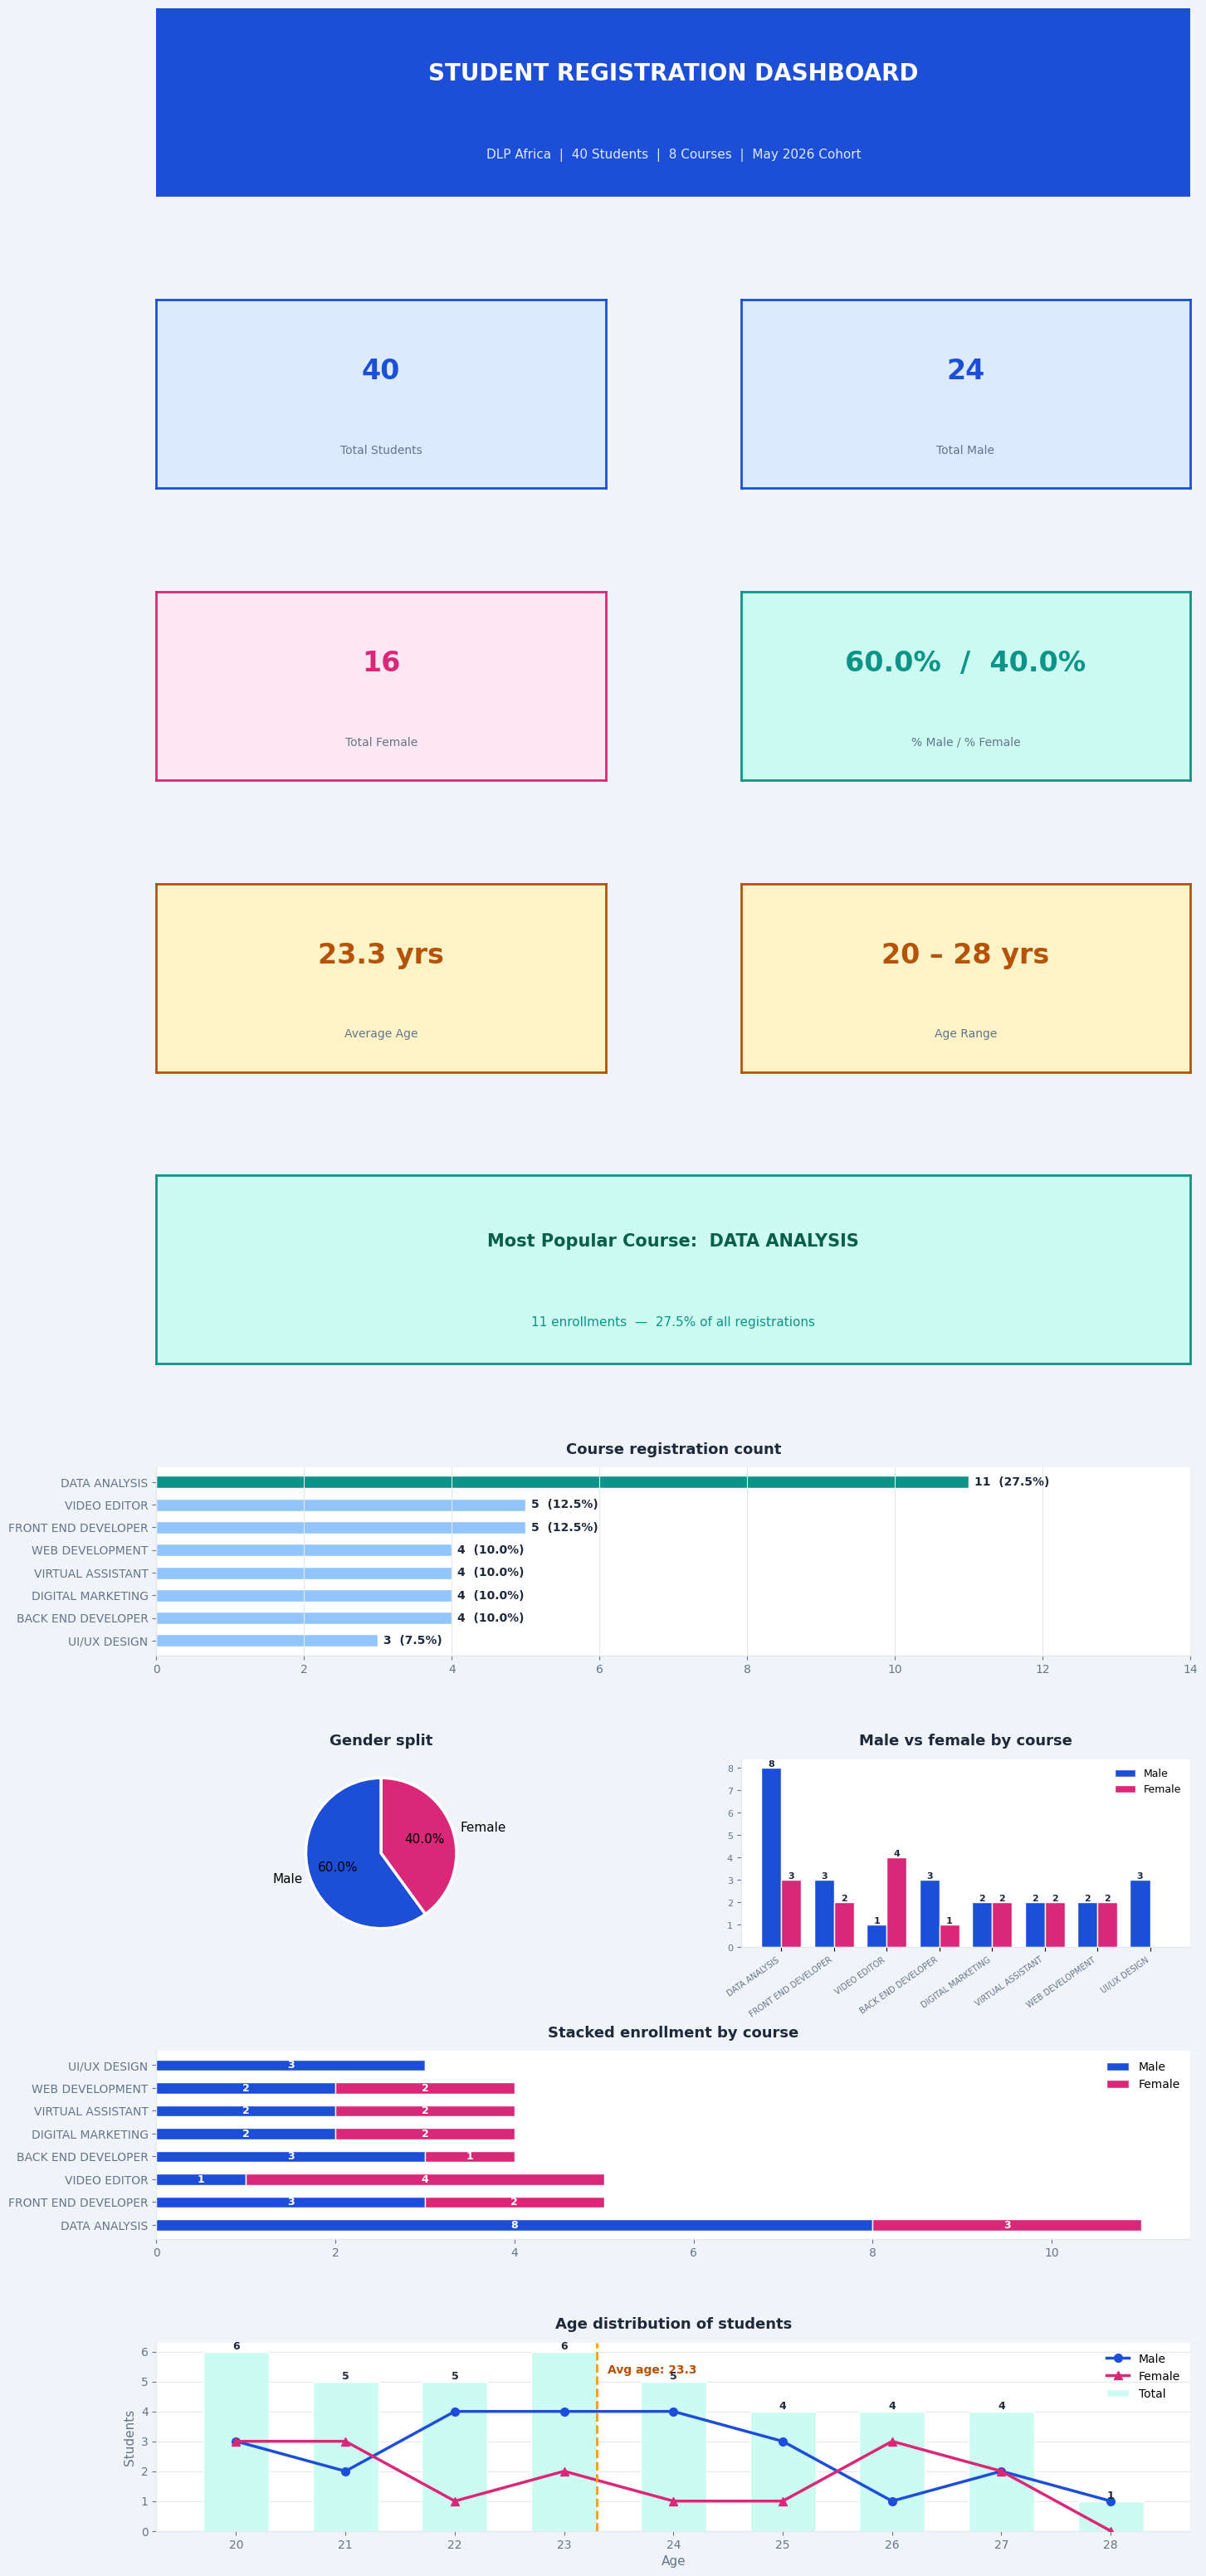

✅ Master dashboard saved as MASTER_DASHBOARD.png


In [30]:
# ── Rebuild all variables so this cell works standalone ───────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

course = (df.groupby("COURSE").size()
            .reset_index(name="COUNT")
            .sort_values("COUNT", ascending=False)
            .reset_index(drop=True))
course["PCT"] = (course["COUNT"] / len(df) * 100).round(1)

gender = (df.groupby(["COURSE","GENDER"]).size().unstack(fill_value=0).reset_index())
gender.columns.name = None
gender["TOTAL"] = gender["MALE"] + gender["FEMALE"]
gender = gender.sort_values("TOTAL", ascending=False).reset_index(drop=True)

age = (df.groupby("AGE")
         .agg(COUNT=("ID","count"),
              MALE=("GENDER", lambda x: (x=="MALE").sum()),
              FEMALE=("GENDER", lambda x: (x=="FEMALE").sum()))
         .reset_index())

age_grp = (df.groupby("AGE GROUP").size()
             .reset_index(name="COUNT")
             .sort_values("AGE GROUP"))
age_grp["PCT"] = (age_grp["COUNT"] / len(df) * 100).round(1)

total      = len(df)
total_male = (df["GENDER"] == "MALE").sum()
total_fem  = (df["GENDER"] == "FEMALE").sum()
pct_male   = round(total_male / total * 100, 1)
pct_fem    = round(total_fem  / total * 100, 1)
avg_age    = round(df["AGE"].mean(), 1)
top_course = df["COURSE"].value_counts().idxmax()
top_count  = df["COURSE"].value_counts().max()

# ── THEME COLORS — Light professional ─────────────────────────────────────
BG_PAGE    = "#F0F4F8"
BG_CARD    = "#FFFFFF"
BG_HEADER  = "#1D4ED8"
TEAL       = "#0D9488"
BLUE       = "#1D4ED8"
PINK       = "#DB2777"
NAVY       = "#1E293B"
GRAY       = "#64748B"
LIGHT_BLUE = "#DBEAFE"
LIGHT_TEAL = "#CCFBF1"
LIGHT_PINK = "#FCE7F3"
LIGHT_GOLD = "#FEF3C7"
GRP_COLORS = ["#0D9488", "#1D4ED8", "#F59E0B"]
WHITE      = "#FFFFFF"

# ── FIGURE — Portrait / vertical layout ───────────────────────────────────
fig = plt.figure(figsize=(14, 32), facecolor=BG_PAGE)
gs  = gridspec.GridSpec(
    9, 2,
    figure=fig,
    hspace=0.55,
    wspace=0.30,
    top=0.97,
    bottom=0.02,
    left=0.07,
    right=0.96
)

# ── Title header bar ──────────────────────────────────────────────────────
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(BG_HEADER)
ax_title.set_xticks([]); ax_title.set_yticks([])
for sp in ax_title.spines.values():
    sp.set_visible(False)
ax_title.text(0.5, 0.65,
              "STUDENT REGISTRATION DASHBOARD",
              transform=ax_title.transAxes,
              ha="center", va="center",
              fontsize=20, fontweight="bold", color=WHITE)
ax_title.text(0.5, 0.22,
              "DLP Africa  |  40 Students  |  8 Courses  |  May 2026 Cohort",
              transform=ax_title.transAxes,
              ha="center", va="center",
              fontsize=11, color=LIGHT_BLUE)

# ── Row 1: KPI cards (2 per row across 2 columns) ─────────────────────────
kpi_data = [
    ("Total Students",     str(total),                   BLUE,  LIGHT_BLUE),
    ("Total Male",         str(total_male),              BLUE,  LIGHT_BLUE),
    ("Total Female",       str(total_fem),               PINK,  LIGHT_PINK),
    ("% Male / % Female",  f"{pct_male}%  /  {pct_fem}%",TEAL, LIGHT_TEAL),
    ("Average Age",        f"{avg_age} yrs",             "#B45309", LIGHT_GOLD),
    ("Age Range",          "20 – 28 yrs",                "#B45309", LIGHT_GOLD),
]

kpi_positions = [(1,0),(1,1),(2,0),(2,1),(3,0),(3,1)]

for (r, c), (label, value, vc, bg) in zip(kpi_positions, kpi_data):
    ax = fig.add_subplot(gs[r, c])
    ax.set_facecolor(bg)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(vc)
        sp.set_linewidth(2)
    ax.text(0.5, 0.62, value,
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=24, fontweight="bold", color=vc)
    ax.text(0.5, 0.20, label,
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=10, color=GRAY)

# ── Row 4: Most popular course callout ────────────────────────────────────
ax_top = fig.add_subplot(gs[4, :])
ax_top.set_facecolor(LIGHT_TEAL)
ax_top.set_xticks([]); ax_top.set_yticks([])
for sp in ax_top.spines.values():
    sp.set_edgecolor(TEAL); sp.set_linewidth(2)
ax_top.text(0.5, 0.65,
            f"Most Popular Course:  {top_course}",
            transform=ax_top.transAxes,
            ha="center", va="center",
            fontsize=15, fontweight="bold", color="#065F46")
ax_top.text(0.5, 0.22,
            f"{top_count} enrollments  —  27.5% of all registrations",
            transform=ax_top.transAxes,
            ha="center", va="center",
            fontsize=11, color=TEAL)

# ── Row 5: Course count bar chart (full width) ────────────────────────────
ax_course = fig.add_subplot(gs[5, :])
ax_course.set_facecolor(BG_CARD)
for sp in ax_course.spines.values():
    sp.set_edgecolor("#E2E8F0"); sp.set_linewidth(1)
course_s = course.sort_values("COUNT", ascending=True).reset_index(drop=True)
clrs = [TEAL if v == course_s["COUNT"].max() else "#93C5FD"
        for v in course_s["COUNT"]]
bars = ax_course.barh(course_s["COURSE"], course_s["COUNT"],
                      color=clrs, edgecolor=WHITE, height=0.55)
for bar, pct_val in zip(bars, course_s["PCT"]):
    ax_course.text(bar.get_width() + 0.08,
                   bar.get_y() + bar.get_height() / 2,
                   f"{int(bar.get_width())}  ({pct_val}%)",
                   va="center", fontsize=10,
                   fontweight="bold", color=NAVY)
ax_course.set_title("Course registration count",
                    fontsize=13, fontweight="bold",
                    color=NAVY, pad=12)
ax_course.tick_params(axis="both", colors=GRAY, labelsize=10)
ax_course.spines[["top","right"]].set_visible(False)
ax_course.set_xlim(0, course_s["COUNT"].max() + 3)
ax_course.grid(axis="x", color="#E2E8F0", linewidth=0.8)

# ── Row 6: Gender pie + Gender grouped bar ────────────────────────────────
ax_pie = fig.add_subplot(gs[6, 0])
ax_pie.set_facecolor(BG_CARD)
for sp in ax_pie.spines.values():
    sp.set_edgecolor("#E2E8F0")
ax_pie.pie(
    [total_male, total_fem],
    labels=["Male", "Female"],
    autopct="%1.1f%%",
    colors=[BLUE, PINK],
    startangle=90,
    wedgeprops=dict(edgecolor=WHITE, linewidth=2.5),
    textprops=dict(fontsize=11)
)
ax_pie.set_title("Gender split", fontsize=13,
                 fontweight="bold", color=NAVY, pad=12)

ax_gb = fig.add_subplot(gs[6, 1])
ax_gb.set_facecolor(BG_CARD)
for sp in ax_gb.spines.values():
    sp.set_edgecolor("#E2E8F0")
x = np.arange(len(gender)); w = 0.38
b1 = ax_gb.bar(x - w/2, gender["MALE"],   w, label="Male",
               color=BLUE, edgecolor=WHITE)
b2 = ax_gb.bar(x + w/2, gender["FEMALE"], w, label="Female",
               color=PINK, edgecolor=WHITE)
for b in list(b1) + list(b2):
    h = b.get_height()
    if h > 0:
        ax_gb.text(b.get_x() + b.get_width() / 2,
                   h + 0.05, int(h),
                   ha="center", fontsize=8,
                   fontweight="bold", color=NAVY)
ax_gb.set_xticks(x)
ax_gb.set_xticklabels(gender["COURSE"], rotation=35,
                      ha="right", fontsize=7, color=GRAY)
ax_gb.tick_params(axis="y", colors=GRAY, labelsize=8)
ax_gb.set_title("Male vs female by course",
                fontsize=13, fontweight="bold",
                color=NAVY, pad=12)
ax_gb.legend(fontsize=9, frameon=False)
ax_gb.spines[["top","right"]].set_visible(False)
ax_gb.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── Row 7: Stacked bar (full width) ───────────────────────────────────────
ax_st = fig.add_subplot(gs[7, :])
ax_st.set_facecolor(BG_CARD)
for sp in ax_st.spines.values():
    sp.set_edgecolor("#E2E8F0")
ax_st.barh(gender["COURSE"], gender["MALE"],
           color=BLUE, height=0.5,
           label="Male", edgecolor=WHITE)
ax_st.barh(gender["COURSE"], gender["FEMALE"],
           left=gender["MALE"],
           color=PINK, height=0.5,
           label="Female", edgecolor=WHITE)
for i, row in gender.iterrows():
    if row["MALE"] > 0:
        ax_st.text(row["MALE"] / 2, i,
                   int(row["MALE"]),
                   ha="center", va="center",
                   fontsize=9, fontweight="bold", color=WHITE)
    if row["FEMALE"] > 0:
        ax_st.text(row["MALE"] + row["FEMALE"] / 2, i,
                   int(row["FEMALE"]),
                   ha="center", va="center",
                   fontsize=9, fontweight="bold", color=WHITE)
ax_st.tick_params(axis="both", colors=GRAY, labelsize=10)
ax_st.set_title("Stacked enrollment by course",
                fontsize=13, fontweight="bold",
                color=NAVY, pad=12)
ax_st.legend(fontsize=10, frameon=False)
ax_st.spines[["top","right"]].set_visible(False)

# ── Row 8: Age distribution (full width) ──────────────────────────────────
ax_age = fig.add_subplot(gs[8, :])
ax_age.set_facecolor(BG_CARD)
for sp in ax_age.spines.values():
    sp.set_edgecolor("#E2E8F0")
ax_age.bar(age["AGE"], age["COUNT"],
           color=LIGHT_TEAL, edgecolor=WHITE,
           width=0.6, zorder=2, label="Total")
ax_age.plot(age["AGE"], age["MALE"],   "o-",
            color=BLUE, linewidth=2.5,
            markersize=7, label="Male", zorder=3)
ax_age.plot(age["AGE"], age["FEMALE"], "^-",
            color=PINK, linewidth=2.5,
            markersize=7, label="Female", zorder=3)
ax_age.axvline(avg_age, color="#F59E0B",
               linewidth=2, linestyle="--", zorder=4)
ax_age.text(avg_age + 0.1,
            age["COUNT"].max() * 0.88,
            f"Avg age: {avg_age}",
            color="#B45309", fontsize=10, fontweight="bold")
for _, row in age.iterrows():
    ax_age.text(row["AGE"], row["COUNT"] + 0.08,
                int(row["COUNT"]),
                ha="center", fontsize=9,
                fontweight="bold", color=NAVY)
ax_age.set_xticks(age["AGE"])
ax_age.tick_params(axis="both", colors=GRAY, labelsize=10)
ax_age.set_xlabel("Age", fontsize=11, color=GRAY)
ax_age.set_ylabel("Students", fontsize=11, color=GRAY)
ax_age.set_title("Age distribution of students",
                 fontsize=13, fontweight="bold",
                 color=NAVY, pad=12)
ax_age.legend(fontsize=10, frameon=False)
ax_age.spines[["top","right"]].set_visible(False)
ax_age.grid(axis="y", color="#E2E8F0", linewidth=0.8)

plt.savefig("MASTER_DASHBOARD.png", dpi=150,
            bbox_inches="tight", facecolor=BG_PAGE)
plt.show()
print("✅ Master dashboard saved as MASTER_DASHBOARD.png")